# Accessing the LSST SN Ia Simulations

This notebook shows how to read and explore the simulated LSST SN Ia light curves produced by `LSST_snia_sims.ipynb`.

The output is stored as a [nested-pandas](https://nested-pandas.readthedocs.io/en/latest/index.html) `NestedFrame` where each row is one supernova and the `lightcurve` column holds the full multi-band light curve as a nested table.

General documentation on the results and output format produced by `lightcurvelynx` can be found at the [lightcurvelynx Results and Output](https://lightcurvelynx.readthedocs.io/en/latest/results_and_output.html) docs.

In [1]:
import nested_pandas as npd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Read the parquet file

Use `nested_pandas.read_parquet` — standard `pandas.read_parquet` will not correctly restore the nested `lightcurve` structure.

In [2]:
df = npd.read_parquet("output/lsst_snia_results.parquet")
print(f"{len(df)} simulated SNe Ia")
df.head()

100 simulated SNe Ia


id         ra        dec   nobs            t0         z     source_t0  \
0   0  10.550932 -43.616246  12934  61141.239671  0.691652  61141.239671   
1   1  11.738051 -43.135705    944  61504.697983  0.621869  61504.697983   
2   2   8.659809 -42.228106   1220  60989.488471  0.323679  60989.488471   
3   3   8.523033  -42.93501  12934  62558.181666   0.65458  62558.181666   
4   4   8.341835 -43.629485  12934  61756.957745  0.250004  61756.957745   

   source_x0  source_x1  source_c  source_redshift  source_ra  source_dec  \
0   0.000007   1.201751  0.001851         0.691652  10.550932  -43.616246   
1    0.00001   0.469707 -0.056081         0.621869  11.738051  -43.135705   
2   0.000022  -0.395889  0.109395         0.323679   8.659809  -42.228106   
3   0.000007   0.118151 -0.015111          0.65458   8.523033   -42.93501   
4   0.000064  -0.287901 -0.046625         0.250004   8.341835  -43.629485   

   x0_func_distmod                                         lightcurve  \
0         43.10041  [{mjd: 60990.033239, filter: 'y', flux: -168.9...   
1        42.819986  [{mjd: 61032.059159, filter: 'z', flux: 102.24...   
2        41.138755  [{mjd: 61002.087705, filter: 'r', flux: 4164.7...   
3        42.954973  [{mjd: 60990.033239, filter: 'y', flux: -496.4...   
4        40.496249  [{mjd: 60990.033239, filter: 'y', flux: 569.26...   

                                              params  
0  {'radec.ra': 10.550932050175794, 'radec.dec': ...  
1  {'radec.ra': 11.738051069189169, 'radec.dec': ...  
2  {'radec.ra': 8.659808911260802, 'radec.dec': -...  
3  {'radec.ra': 8.523032751799668, 'radec.dec': -...  
4  {'radec.ra': 8.341835267039377, 'radec.dec': -...

## Column descriptions

### Top-level columns

| Column | Type | Description |
|--------|------|-------------|
| `id` | int64 | Unique SN identifier |
| `ra` | float64 | Right ascension (deg) |
| `dec` | float64 | Declination (deg) |
| `nobs` | int64 | Total number of observations |
| `t0` | float64 | Peak time (MJD) |
| `z` | float64 | Redshift |
| `source_t0` | float64 | SALT3 model peak time (MJD) |
| `source_x0` | float64 | SALT3 x0 — flux normalization; encodes distance and absolute magnitude |
| `source_x1` | float64 | SALT3 x1 — light curve shape (stretch); positive = broader/brighter |
| `source_c` | float64 | SALT3 c — color; positive = redder |
| `source_redshift` | float64 | Redshift from the source model node |
| `source_ra` | float64 | RA from the source model node (deg) |
| `source_dec` | float64 | Dec from the source model node (deg) |
| `x0_func_distmod` | float64 | Distance modulus μ used to set x0 |
| `lightcurve` | nested | Per-observation light curve table (see below) |
| `params` | nested | Full computational-graph node outputs for all pipeline parameters; can be used to recreate the simulations |

> **Note:** By default, `simulate_lightcurves` outputs only `id`, `ra`, `dec`, `nobs`, `t0`, `z`, `lightcurve`, and `params`. Columns such as `source_t0`, `source_x0`, etc. are sampled parameters that can be promoted to top-level columns by passing `param_cols=param_cols` to `simulate_lightcurves`, or added after the fact using the helper functions described in the [lightcurvelynx Results and Output docs](https://lightcurvelynx.readthedocs.io/en/latest/results_and_output.html#adding-parameters-as-columns). Columns from the observation table (e.g. `zp`) can also be saved into the nested `lightcurve` table by passing `obstable_save_cols` (e.g. `obstable_save_cols=["zp"]`) to `simulate_lightcurves`.

### Nested `lightcurve` columns

Access via `df.iloc[i].lightcurve` or `df['lightcurve'].nest.to_flat()`.

| Column | Type | Description |
|--------|------|-------------|
| `mjd` | float64 | Modified Julian Date of the observation |
| `filter` | str | LSST filter: u, g, r, i, z, or y |
| `flux` | float64 | Measured flux with photon noise (nJy) |
| `fluxerr` | float64 | 1-σ flux uncertainty (nJy) |
| `flux_perfect` | float64 | Noiseless model flux (nJy) |
| `survey_idx` | int64 | Row index in the OpSim observation table |
| `obs_idx` | int64 | Observation index within this SN |
| `is_saturated` | bool | True if the source is brighter than the detector saturation limit |
| `zp` | float64 | Zero point (nJy) |

## Access a single SN light curve

Each row of the `NestedFrame` is a named tuple. The `lightcurve` attribute is a regular `pandas.DataFrame`.

In [3]:
sn = df.iloc[0]
lc = sn.lightcurve

print(f"SN id={sn.id}  z={sn.z:.3f}  x1={sn.source_x1:.2f}  c={sn.source_c:.3f}")
print(f"{len(lc)} observations across {lc['filter'].nunique()} filters")
lc.head(10)

SN id=0  z=0.692  x1=1.20  c=0.002
12934 observations across 6 filters


,mjd,filter,flux,fluxerr,flux_perfect,survey_idx,obs_idx,is_saturated,zp
0,60990.033239,y,-168.983012,642.156675,0.0,0,0,False,2.280864
1,60990.033633,y,-389.284530,640.515035,0.0,0,1,False,2.280328
2,60990.086451,r,96.120827,113.327671,0.0,0,2,False,0.549442
3,60990.086850,r,121.085170,124.762321,0.0,0,3,False,0.549454
4,60990.088829,z,-12.901155,338.666334,0.0,0,4,False,0.934886
5,60990.089228,z,-33.420117,338.741816,0.0,0,5,False,0.934901
6,60991.083535,g,-54.484852,51.185104,0.0,0,6,False,0.480981
7,60991.083934,g,83.411133,51.191498,0.0,0,7,False,0.480997
8,60991.085913,i,2.706514,119.266884,0.0,0,8,False,0.653667
9,60991.086312,i,87.208853,119.290018,0.0,0,9,False,0.653680


## Plot the light curve

Points with error bars show the noisy flux; solid lines show the noiseless model. Phase is measured relative to SALT3 peak time.

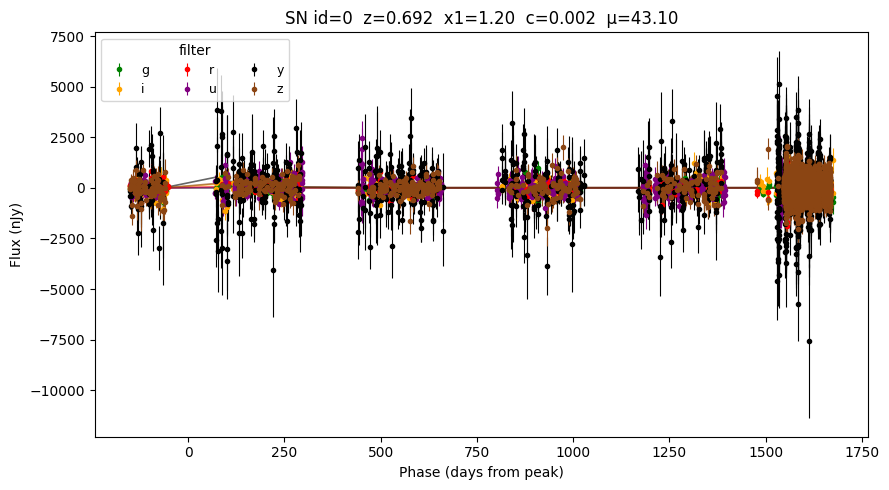

In [4]:
FILTER_COLORS = {"u": "purple", "g": "green", "r": "red",
                 "i": "orange", "z": "saddlebrown", "y": "black"}

fig, ax = plt.subplots(figsize=(9, 5))

for filt, group in lc.groupby("filter"):
    phase = group["mjd"] - sn.source_t0
    color = FILTER_COLORS.get(filt, "gray")
    ax.errorbar(phase, group["flux"], yerr=group["fluxerr"],
                fmt="o", ms=3, lw=0.8, color=color, label=filt)
    ax.plot(phase, group["flux_perfect"], "-", lw=1.2, alpha=0.6, color=color)

ax.set_xlabel("Phase (days from peak)")
ax.set_ylabel("Flux (nJy)")
ax.set_title(
    f"SN id={sn.id}  z={sn.z:.3f}  "
    f"x1={sn.source_x1:.2f}  c={sn.source_c:.3f}  "
    f"\u03bc={sn.x0_func_distmod:.2f}"
)
ax.legend(ncol=3, fontsize=9, title="filter")
plt.tight_layout()
plt.show()

### Detections only (SNR > 5)

/tmp/claude-501/ipykernel_27490/1363451994.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(ncol=3, fontsize=9, title="filter")


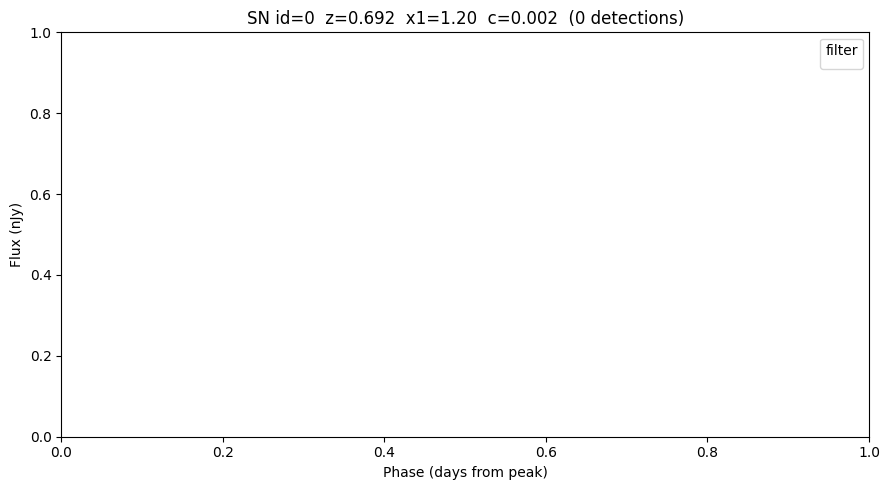

In [5]:
detections = lc[(lc["flux"] / lc["fluxerr"] > 5) & ~lc["is_saturated"]]

fig, ax = plt.subplots(figsize=(9, 5))

for filt, group in detections.groupby("filter"):
    phase = group["mjd"] - sn.source_t0
    color = FILTER_COLORS.get(filt, "gray")
    ax.errorbar(phase, group["flux"], yerr=group["fluxerr"],
                fmt="o", ms=4, lw=0.8, color=color, label=filt)

ax.set_xlabel("Phase (days from peak)")
ax.set_ylabel("Flux (nJy)")
ax.set_title(
    f"SN id={sn.id}  z={sn.z:.3f}  "
    f"x1={sn.source_x1:.2f}  c={sn.source_c:.3f}  "
    f"({len(detections)} detections)"
)
ax.legend(ncol=3, fontsize=9, title="filter")
plt.tight_layout()
plt.show()

## Summary statistics

In [6]:
df[["z", "source_x1", "source_c", "nobs"]].describe().round(3)

,z,source_x1,source_c,nobs
count,100.0,100.0,100.0,100.0
mean,0.516,-0.043,-0.014,10774.99
std,0.145,0.938,0.066,3886.507
min,0.143,-2.917,-0.146,4.0
25%,0.443,-0.406,-0.068,10221.25
50%,0.551,0.091,-0.014,12934.0
75%,0.636,0.654,0.027,12934.0
max,0.692,1.313,0.124,12934.0
